# Notebook: Scaling the Results worldwide

## 0. Load packages

In [11]:
# Packages
import pandas as pd
import numpy as np
import tjn_tools
from config import *
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Show columns and select data format
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

## Step 1. Estimate Number of MNEs by country

This is done by checking how many MNEs each country report in their own country each year

In [12]:
cbcr_sample = pd.read_csv('../data/2025/final/cbcr_dataset_total_allsubgroups.csv')

# Keep if iso_parent is equal to iso_partner
cbcr_sample = cbcr_sample[cbcr_sample['iso_parent'] == cbcr_sample['iso_partner']]

# Keep iso_parent, iso_partner, year, and n_cbcr
cbcr_sample = cbcr_sample[['iso_parent', 'iso_partner', 'year', 'n_cbcr']]

cbcr_sample

,iso_parent,iso_partner,year,n_cbcr
2,ARE,ARE,2021,59.00
151,ARG,ARG,2017,15.00
152,ARG,ARG,2018,21.00
153,ARG,ARG,2019,25.00
154,ARG,ARG,2020,30.00
...,...,...,...,...
14881,ZAF,ZAF,2017,51.00
14882,ZAF,ZAF,2018,58.00
14883,ZAF,ZAF,2019,54.00
14884,ZAF,ZAF,2020,58.00


## Step 2. Estimate the total number of MNEs reported each year.

In [13]:
# In cbcr_sample, sum n_cbcr by year
cbcr_sample_sum_cbcr = cbcr_sample.groupby(['year']).sum()

# Drop iso_parent and iso_partner
cbcr_sample_sum_cbcr = cbcr_sample_sum_cbcr.drop(columns=['iso_parent', 'iso_partner'])

cbcr_sample_sum_cbcr

,n_cbcr
year,
2016,"3,628.00"
2017,"5,884.00"
2018,"6,645.00"
2019,"7,074.00"
2020,"7,470.00"
2021,"7,628.00"


## Step 3. Generate an estimate of how many MNEs there are in the world

We do that by looking at the growth of MNEs reported in the countries that are present since 2016.

- So the 26 reporting countries in 2016 report 3628 MNEs in 2016, and they report 4668 MNEs in 2017, an increase of 28%
- We assume that in the number of MNEs in the world increases at the same rate. We also assume that in 2021, there were 10000 MNEs, so we do an inverse scaled down.
- In short, since the 26 reporting countries in 2021 report 5655 MNEs, an increase of 2% wrt to the 5541 of 2020, if the world has 10000 MNEs in 2021, and it comes from an increase of 2% in the previous year, it must have had 9798 multinationals the year before in 2021.



In [14]:
# Generate list of countries if year = 2016
cbcr_sample_2016 = cbcr_sample[cbcr_sample['year'] == 2016]

# Keep iso_parent column only
cbcr_sample_2016 = cbcr_sample_2016[['iso_parent']]

# Generate a list from iso_parent
cbcr_sample_2016 = cbcr_sample_2016['iso_parent'].unique()

# Keep if iso_parent is in cbcr_sample_2016 in cbcr_sample
cbcr_sample = cbcr_sample[cbcr_sample['iso_parent'].isin(cbcr_sample_2016)]

cbcr_reporters_2016 = cbcr_sample.groupby(['year']).sum()

# Drop iso_parent and iso_partner
cbcr_reporters_2016 = cbcr_reporters_2016.drop(columns=['iso_parent', 'iso_partner'])

# Generate a new variable defined as n_cbcr divided by 5655
cbcr_reporters_2016['total_world_cbcr'] = (cbcr_reporters_2016['n_cbcr'] / 5655)*10000

cbcr_reporters_2016

,n_cbcr,total_world_cbcr
year,,
2016,"3,628.00","6,415.56"
2017,"4,669.00","8,256.41"
2018,"4,988.00","8,820.51"
2019,"5,227.00","9,243.15"
2020,"5,541.00","9,798.41"
2021,"5,655.00","10,000.00"


## Step 4. Calculate the percentage of MNEs not counted in the dataset by dividing the number of CBCR in the dataset by the Number of total CBCR

In [15]:
# Merge cbcr_sample_sum_cbcr and cbcr_reporters_2016
world_mnes_count = cbcr_sample_sum_cbcr.merge(cbcr_reporters_2016, on='year', how='left')

# Rename n_cbcr_x and n_cbcr_y as n_cbcr and n_cbcr_reporters_2016
world_mnes_count = world_mnes_count.rename(columns={'n_cbcr_x': 'n_cbcr', 'n_cbcr_y': 'n_cbcr_reporters_2016'})

# Generate a new variable called uncounted_mnes which should be: 1 - (n_cbcr / share_2021_cbcr)
world_mnes_count['percentage_uncounted_mnes'] = 1 - (world_mnes_count['n_cbcr'] / world_mnes_count['total_world_cbcr'])

# Reset index
world_mnes_count = world_mnes_count.reset_index()

# Keep year and uncounted_mnes only
world_mnes_count = world_mnes_count[['year', 'percentage_uncounted_mnes']]

world_mnes_count

,year,percentage_uncounted_mnes
0,2016,0.43
1,2017,0.29
2,2018,0.25
3,2019,0.23
4,2020,0.24
5,2021,0.24


## Step 5. Concatenate the original SOTJ data

In [16]:
# Concatenate Final Results
sotj_aggregate_2016 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2016.csv')
sotj_aggregate_2017 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2017.csv')
sotj_aggregate_2018 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2018.csv')
sotj_aggregate_2019 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2019.csv')
sotj_aggregate_2020 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2020.csv')
sotj_aggregate_2021 = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_sample_aggregate_results_2021.csv')

#Concatenate all of the above
sotj_aggregate = pd.concat([sotj_aggregate_2016, sotj_aggregate_2017, sotj_aggregate_2018, sotj_aggregate_2019, sotj_aggregate_2020, sotj_aggregate_2021])

sotj_aggregate

,year,total_positive_misalignment,total_negative_misalignment,total_profits,misaligned_of_total_profits,total_tax_revenue_loss,total_tax_revenue_gain,average_tax_revenue_loss_pct_of_gvt_health_expenditure,average_tax_revenue_loss_pct_of_total_tax_revenues
0,2016,"519,888.17","519,888.17","2,661,709.50",0.20,"143,680.75","40,301.13",0.09,0.01
0,2017,"996,826.57","996,826.57","5,272,673.81",0.19,"270,600.93","70,351.66",0.32,0.39
0,2018,"976,682.66","976,682.66","5,995,304.49",0.16,"262,885.88","85,824.87",0.24,0.02
0,2019,"1,143,036.03","1,143,036.03","6,044,144.78",0.19,"299,148.98","107,262.24",0.37,0.02
0,2020,"1,044,895.00","1,044,895.00","4,430,343.97",0.24,"262,580.97","92,188.28",0.31,0.03
0,2021,"1,398,026.72","1,398,026.72","8,934,921.85",0.16,"343,209.76","123,079.35",0.40,0.06


## Step 6. Scale up the misalignment by the percentage_uncounted_mnes

In [17]:
# Merge sotj_scaled_up and world_mnes_count
sotj_scaled_up = sotj_aggregate.merge(world_mnes_count, on='year', how='left')

# Generate a new variable called scaled_up_misalignment calculated as: total_positive_misalignment * (1+ uncounted_mnes)
sotj_scaled_up['scaled_up_misalignment'] = sotj_scaled_up['total_positive_misalignment'] * (1 + sotj_scaled_up['percentage_uncounted_mnes'])
sotj_scaled_up

,year,total_positive_misalignment,total_negative_misalignment,total_profits,misaligned_of_total_profits,total_tax_revenue_loss,total_tax_revenue_gain,average_tax_revenue_loss_pct_of_gvt_health_expenditure,average_tax_revenue_loss_pct_of_total_tax_revenues,percentage_uncounted_mnes,scaled_up_misalignment
0,2016,"519,888.17","519,888.17","2,661,709.50",0.20,"143,680.75","40,301.13",0.09,0.01,0.43,"745,779.58"
1,2017,"996,826.57","996,826.57","5,272,673.81",0.19,"270,600.93","70,351.66",0.32,0.39,0.29,"1,283,256.32"
2,2018,"976,682.66","976,682.66","5,995,304.49",0.16,"262,885.88","85,824.87",0.24,0.02,0.25,"1,217,574.06"
3,2019,"1,143,036.03","1,143,036.03","6,044,144.78",0.19,"299,148.98","107,262.24",0.37,0.02,0.23,"1,411,279.49"
4,2020,"1,044,895.00","1,044,895.00","4,430,343.97",0.24,"262,580.97","92,188.28",0.31,0.03,0.24,"1,293,194.76"
5,2021,"1,398,026.72","1,398,026.72","8,934,921.85",0.16,"343,209.76","123,079.35",0.40,0.06,0.24,"1,729,638.65"


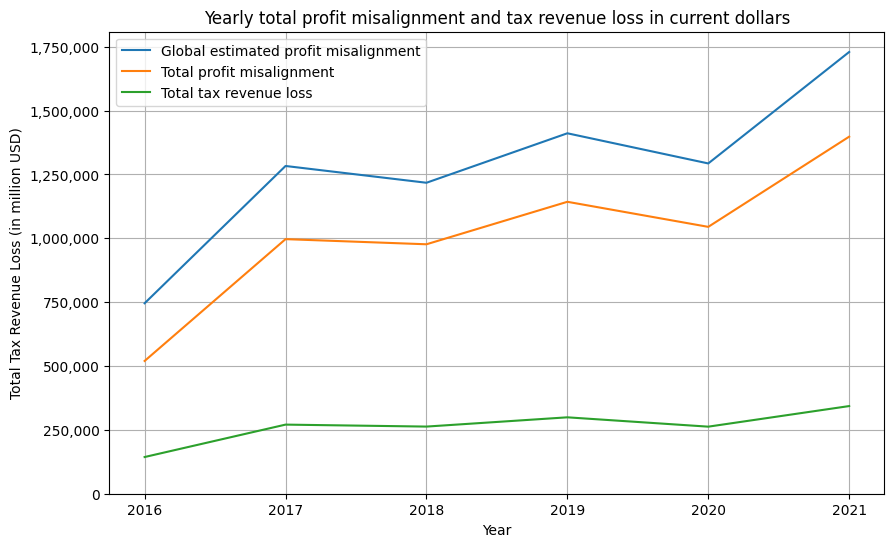

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['scaled_up_misalignment'], label='Global estimated profit misalignment')
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_positive_misalignment'], label='Total profit misalignment')
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_tax_revenue_loss'], label='Total tax revenue loss')

plt.title('Yearly total profit misalignment and tax revenue loss in current dollars')
plt.xlabel('Year')
plt.ylabel('Total Tax Revenue Loss (in million USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()

## Step 7. Deflate the numbers by the following Deflator Factor, from the World Bank

**Fetch original dataset for future reference**

Deflator factor: 

- 2016: 1.1290
- 2017: 1.1055
- 2018: 1.0791	
- 2019: 1.0599	
- 2020: 1.0470	
- 2021: 1.0000

In [19]:
# From sotj_scaled_up, keep scaled_up_misalignment, total_positive_misalignment, total_tax_revenue_loss and year
sotj_scaled_up = sotj_scaled_up[['year', 'scaled_up_misalignment', 'total_positive_misalignment', 'total_tax_revenue_loss']]

#Generate a new variable called deflator which takes the following values for the years: 2016: 1.1290, 2017: 1.1055, 2018: 1.0791, 2019: 1.0599, 2020: 1.0470, 2021: 1.0000
sotj_scaled_up['deflator'] = [1.1290, 1.1055, 1.0791, 1.0599, 1.0470, 1.0000]

# Multiply scaled_up_misalignment, total_positive_misalignment, and total_tax_revenue_loss by deflator
sotj_scaled_up['scaled_up_misalignment'] = sotj_scaled_up['scaled_up_misalignment'] * sotj_scaled_up['deflator']
sotj_scaled_up['total_positive_misalignment'] = sotj_scaled_up['total_positive_misalignment'] * sotj_scaled_up['deflator']
sotj_scaled_up['total_tax_revenue_loss'] = sotj_scaled_up['total_tax_revenue_loss'] * sotj_scaled_up['deflator']


sotj_scaled_up

C:\Users\aliso\AppData\Local\Temp\ipykernel_27448\2619249142.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sotj_scaled_up['deflator'] = [1.1290, 1.1055, 1.0791, 1.0599, 1.0470, 1.0000]
C:\Users\aliso\AppData\Local\Temp\ipykernel_27448\2619249142.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sotj_scaled_up['scaled_up_misalignment'] = sotj_scaled_up['scaled_up_misalignment'] * sotj_scaled_up['deflator']
C:\Users\aliso\AppData\Local\Temp\ipykernel_27448\2619249142.py:9: SettingWithCopyWarning: 
A v

,year,scaled_up_misalignment,total_positive_misalignment,total_tax_revenue_loss,deflator
0,2016,"841,985.14","586,953.74","162,215.57",1.13
1,2017,"1,418,639.86","1,101,991.77","299,149.33",1.11
2,2018,"1,313,884.17","1,053,938.26","283,680.15",1.08
3,2019,"1,495,815.14","1,211,503.89","317,068.01",1.06
4,2020,"1,353,974.91","1,094,005.07","274,922.27",1.05
5,2021,"1,729,638.65","1,398,026.72","343,209.76",1.00


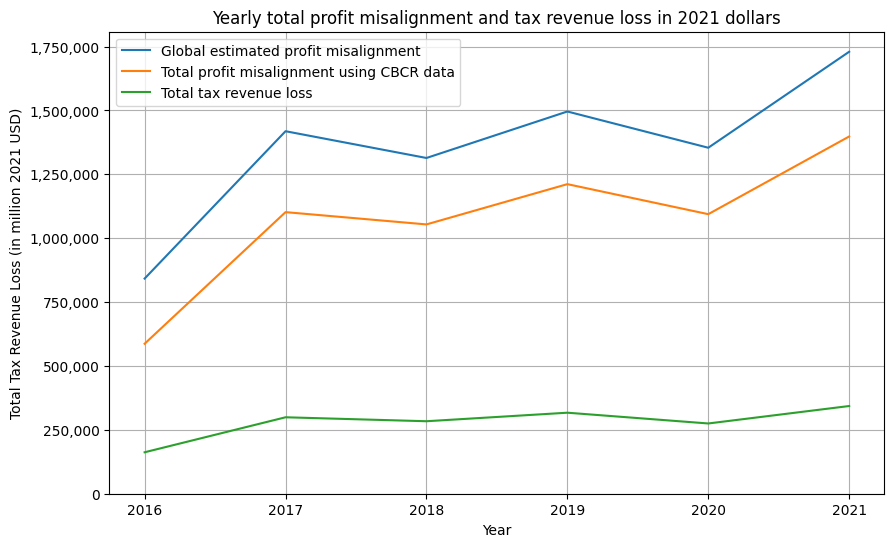

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['scaled_up_misalignment'], label='Global estimated profit misalignment')
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_positive_misalignment'], label='Total profit misalignment using CBCR data')
plt.plot(sotj_scaled_up['year'], sotj_scaled_up['total_tax_revenue_loss'], label='Total tax revenue loss')

plt.title('Yearly total profit misalignment and tax revenue loss in 2021 dollars')
plt.xlabel('Year')
plt.ylabel('Total Tax Revenue Loss (in million 2021 USD)')
plt.ylim(0, )
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(True)
plt.show()